In [1]:
import pandas as pd
import numpy as np

ratings_df = pd.read_csv('train_data_movie_rate.csv')
trust_df = pd.read_csv('train_data_movie_trust.csv')
test_df = pd.read_csv('test_data.csv')

users = ratings_df.groupby('item_id')
print(max(users['item_id']))

(2071, 34224    2071
Name: item_id, dtype: int64)


In [2]:
num_users = 1642
num_items = 2071
ratings_df = ratings_df.groupby(['user_id', 'item_id'])['label'].mean().reset_index()

user_item_matrix = np.zeros((num_users, num_items))
for row in ratings_df.itertuples(index=False):
    user = row.user_id - 1
    item = row.item_id - 1
    user_item_matrix[user, item] = row.label
print(user_item_matrix)

trustor_trustee_matrix = np.zeros((num_users, num_users))
for row in trust_df.itertuples(index=False):
    trustor = row.user_id_trustor - 1
    trustee = row.user_id_trustee - 1
    trustor_trustee_matrix[trustor, trustee] = row.trust_value

print(trustor_trustee_matrix)

[[2.  4.  3.5 ... 0.  0.  0. ]
 [0.  0.  0.  ... 0.  0.  0. ]
 [0.  0.  0.  ... 0.  0.  0. ]
 ...
 [0.  0.  0.  ... 0.  0.  0. ]
 [0.  0.  0.  ... 0.  0.  0. ]
 [0.  0.  0.  ... 0.  0.  0. ]]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


Feature Engineering

In [4]:
user_mean = ratings_df.groupby('user_id')['label'].mean().rename('user_mean')
user_std = ratings_df.groupby('user_id')['label'].std().rename('user_std')
item_mean = ratings_df.groupby('item_id')['label'].mean().rename('item_mean')
item_std = ratings_df.groupby('item_id')['label'].std().rename('item_std')
user_rating_count = ratings_df.groupby('user_id').size().rename('user_rating_count')
item_rating_count = ratings_df.groupby('item_id').size().rename('item_rating_count')

Trustees Rates

In [5]:
def trustees_features(df):

    trustees_rate_means = []
    trustees_rate_stds = []
    trustees_seens = []
    trustees_nums = []

    for row in df.itertuples(index=False):
        user = row.user_id
        item = row.item_id
        user_trustees = np.where(trustor_trustee_matrix[user - 1] > 0)[0]
        
        trustees_ratings = [user_item_matrix[t][item - 1] for t in user_trustees if user_item_matrix[t][item - 1] > 0]
        trustees_seens.append(len(trustees_ratings))
        trustees_nums.append(len(user_trustees))

        if trustees_ratings:
            trustees_rate_means.append(np.mean(trustees_ratings))
            trustees_rate_stds.append(np.std(trustees_ratings))
        else:
            trustees_rate_means.append(np.nan)
            trustees_rate_stds.append(np.nan)
        
        
    return trustees_rate_means, trustees_rate_stds, trustees_seens, trustees_nums

Clustering On Items

In [6]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

movie_rating_matrix = user_item_matrix.T

scaler = StandardScaler()
movie_rating_matrix_scaled = scaler.fit_transform(movie_rating_matrix)

pca = PCA(n_components=60, random_state=42)
movie_pca = pca.fit_transform(movie_rating_matrix_scaled)

kmeans = KMeans(n_clusters=10, random_state=42, n_init='auto')
item_clusters = kmeans.fit_predict(movie_pca)

from collections import defaultdict
cluster_items = defaultdict(list)
for item_id, cluster_id in enumerate(item_clusters):
    cluster_items[cluster_id].append(item_id)

def clusters_features(df):
    cluster_sizes = []
    cluster_avg_ratings = []
    for row in df.itertuples(index=False):
        user = row.user_id - 1
        item = row.item_id - 1
        cluster_id = item_clusters[item]
        cluster_item_ids = cluster_items[cluster_id]
        cluster_sizes.append(cluster_id)

        ratings = [user_item_matrix[user][cid] for cid in cluster_item_ids if user_item_matrix[user][cid] > 0]
        if ratings:
            cluster_avg_ratings.append(np.mean(ratings))
        else:
            cluster_avg_ratings.append(np.nan)
            
    return cluster_sizes, cluster_avg_ratings
        

Adding All Features To Dataframe

In [7]:
# Merge all features into the ratings data
df = ratings_df.copy()
print(df)
df = df.merge(user_mean, on='user_id', how='left')
df = df.merge(user_std, on='user_id', how='left')
df = df.merge(item_mean, on='item_id', how='left')
df = df.merge(item_std, on='item_id', how='left')
df = df.merge(user_rating_count, on='user_id', how='left')
df = df.merge(item_rating_count, on='item_id', how='left')
df['trustees_rate_mean'], df['trustees_rate_std'], df['trustees_seen'], df['num_of_user_trustees'] = trustees_features(df)
df['cluster_avg_rating'], df['cluster_size'] = clusters_features(df)


       user_id  item_id  label
0            1        1    2.0
1            1        2    4.0
2            1        3    3.5
3            1        4    3.0
4            1        5    4.0
...        ...      ...    ...
34290     1508      669    1.0
34291     1508      686    2.5
34292     1508      693    3.5
34293     1508      751    1.0
34294     1508      806    3.5

[34295 rows x 3 columns]


Preprocessing

In [8]:
df['trustees_rate_mean'] = df.apply(
    lambda row: row['item_mean'] if pd.isna(row['trustees_rate_mean']) and row['num_of_user_trustees'] > 0 else -1,
    axis=1
)

df['trustees_rate_std'] = df.apply(
    lambda row: row['item_std'] if pd.isna(row['trustees_rate_std']) and row['num_of_user_trustees'] > 0 else -1,
    axis=1
)

df['cluster_avg_rating'] = df.apply(
    lambda row: row['item_mean'] if pd.isna(row['cluster_avg_rating']) else row['cluster_avg_rating'],
    axis=1
)

In [9]:
from sklearn.preprocessing import StandardScaler

exclude_cols = ['user_id', 'item_id', 'label', 'id']
features_to_scale = [col for col in df.columns if col not in exclude_cols]

In [10]:
df.fillna({'user_std': 0, 'item_std': 0, 'trustees_rate_std': 0}, inplace=True)
print(df.isna().sum())

user_id                 0
item_id                 0
label                   0
user_mean               0
user_std                0
item_mean               0
item_std                0
user_rating_count       0
item_rating_count       0
trustees_rate_mean      0
trustees_rate_std       0
trustees_seen           0
num_of_user_trustees    0
cluster_avg_rating      0
cluster_size            0
dtype: int64


In [11]:
df.to_csv("final.csv")

In [12]:
# from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

X = df.drop(columns=[x for x in exclude_cols if x != 'id'])
y = df['label']

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
print(X_train.shape)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

(27436, 12)


In [14]:
X_val = scaler.transform(X_val)
print(X_val.shape)

(6859, 12)


In [15]:
cat_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.01,
    depth=3,
    loss_function='RMSE',
    verbose=10,
    random_seed=42
)

cat_model.fit(X_train, y_train)
y_pred = cat_model.predict(X_val)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

y_pred = np.round(y_pred.clip(0, 4) * 2) / 2
print(y_pred)

sns.histplot(y_val, bins=20, color='blue', label='Actual Ratings', kde=True, stat='density')
sns.histplot(y_pred, bins=20, color='orange', label='Predicted Ratings', kde=True, stat='density', alpha=0.7)

plt.title('Distribution of Actual vs Predicted Ratings')
plt.xlabel('Rating')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

print("Train mean rating:", y_train.mean())
print("Val mean rating:", y_val.mean())

NameError: name 'CatBoostRegressor' is not defined

In [ ]:
y_pred = cat_model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mae = mean_absolute_error(y_val, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

RMSE: 0.6253
MAE: 0.4348


Preprocessing Test Data

In [19]:
submit_df = test_df.copy()
        
submit_df = submit_df.merge(user_mean, on='user_id', how='left')
submit_df = submit_df.merge(user_std, on='user_id', how='left')
submit_df = submit_df.merge(item_mean, on='item_id', how='left')
submit_df = submit_df.merge(item_std, on='item_id', how='left')
submit_df = submit_df.merge(user_rating_count, on='user_id', how='left')
submit_df = submit_df.merge(item_rating_count, on='item_id', how='left')
submit_df['trustees_rate_mean'], submit_df['trustees_rate_std'], submit_df['trustees_seen'], submit_df['num_of_user_trustees'] = trustees_features(submit_df)
submit_df['cluster_avg_rating'], submit_df['cluster_size'] = clusters_features(submit_df)
submit_df.to_csv("lssubmit_dfjs.csv")

features_to_scale = [col for col in submit_df.columns if col not in exclude_cols]
# scaler = StandardScaler()
# scaler.fit(X)
submit_df.fillna({'user_std': 0, 'item_std': 0, 'trustees_rate_std': 0}, inplace=True)
submit_df[features_to_scale] = scaler.transform(submit_df[features_to_scale])

submit_df.to_csv("slfdjsl.csv")

In [ ]:
X_scaled = scaler.transform(X)

model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=3,
    loss_function='RMSE',
    l2_leaf_reg=20.0,
    verbose=100,
    random_seed=42
)

model.fit(X_scaled, y)

0:	learn: 0.8982228	total: 46.2ms	remaining: 46.2s
100:	learn: 0.6320392	total: 4.73s	remaining: 42.1s
200:	learn: 0.6263180	total: 5.2s	remaining: 20.7s
300:	learn: 0.6240900	total: 5.5s	remaining: 12.8s
400:	learn: 0.6224309	total: 5.81s	remaining: 8.68s
500:	learn: 0.6213164	total: 6.13s	remaining: 6.1s
600:	learn: 0.6203810	total: 6.43s	remaining: 4.27s
700:	learn: 0.6195835	total: 6.75s	remaining: 2.88s
800:	learn: 0.6186952	total: 7.07s	remaining: 1.76s
900:	learn: 0.6178531	total: 7.37s	remaining: 810ms
999:	learn: 0.6170351	total: 7.67s	remaining: 0us


[0]	validation_0-rmse:0.89417
[100]	validation_0-rmse:0.63017
[200]	validation_0-rmse:0.62698
[242]	validation_0-rmse:0.62711
RMSE: 0.6269


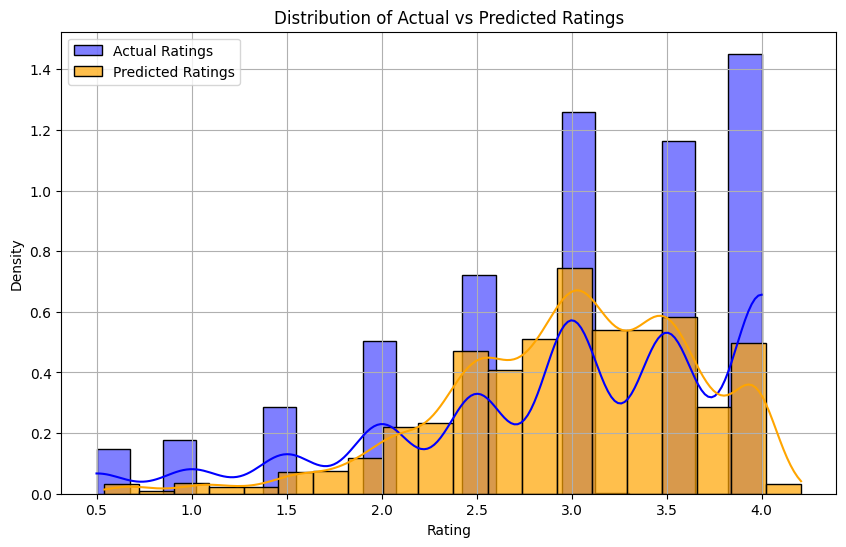

Train mean rating: 3.0071530106429507
Val mean rating: 3.0027336346406184


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    early_stopping_rounds=50,
    random_state=42
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

y_pred = xgb_model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mae = mean_absolute_error(y_val, y_pred)
print(f"RMSE: {rmse:.4f}")

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(y_val, bins=20, color='blue', label='Actual Ratings', kde=True, stat='density')
sns.histplot(y_pred, bins=20, color='orange', label='Predicted Ratings', kde=True, stat='density', alpha=0.7)

plt.title('Distribution of Actual vs Predicted Ratings')
plt.xlabel('Rating')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

print("Train mean rating:", y_train.mean())
print("Val mean rating:", y_val.mean())

RMSE: 0.4095
MAE: 0.4162


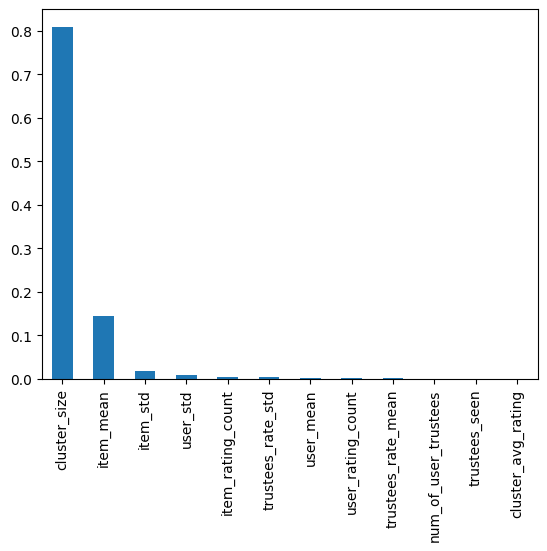

In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

rf_model = RandomForestRegressor(
    n_estimators=1000,       # تعداد درخت‌ها
    max_depth=7,           # حداکثر عمق هر درخت (در صورت نیاز می‌تونی None بذاری)
    min_samples_split=5,    # حداقل نمونه برای تقسیم گره
    min_samples_leaf=2,     # حداقل نمونه در برگ
    random_state=42,
    n_jobs=-1               # استفاده از تمام هسته‌های CPU
)


rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_val)
y_pred = np.round(y_pred.clip(0, 4) * 2) / 2
rmse = mean_squared_error(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)

importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(20).plot(kind='bar')

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")


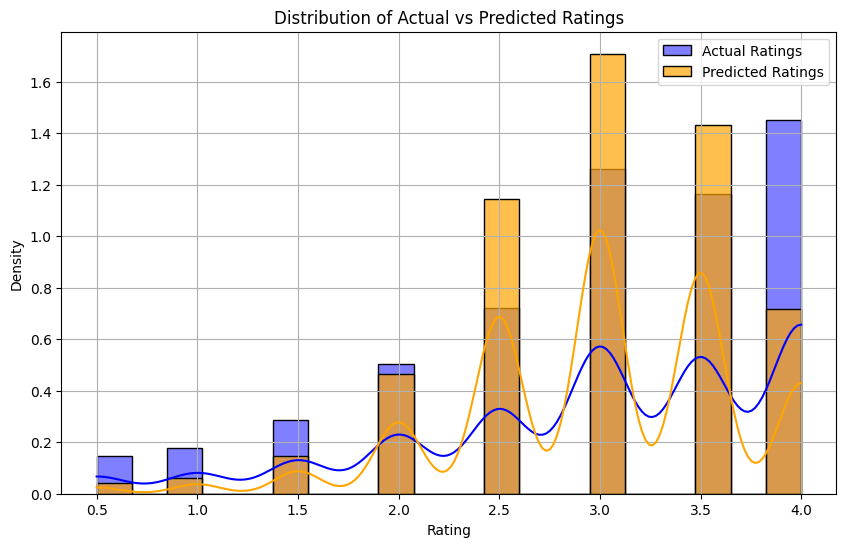

Train mean rating: 3.0071530106429507
Val mean rating: 3.0027336346406184


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(y_val, bins=20, color='blue', label='Actual Ratings', kde=True, stat='density')
sns.histplot(y_pred, bins=20, color='orange', label='Predicted Ratings', kde=True, stat='density', alpha=0.7)

plt.title('Distribution of Actual vs Predicted Ratings')
plt.xlabel('Rating')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

print("Train mean rating:", y_train.mean())
print("Val mean rating:", y_val.mean())

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001016 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1913
[LightGBM] [Info] Number of data points in the train set: 27436, number of used features: 12
[LightGBM] [Info] Start training from score 3.007153
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

c:\Users\Shahab\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


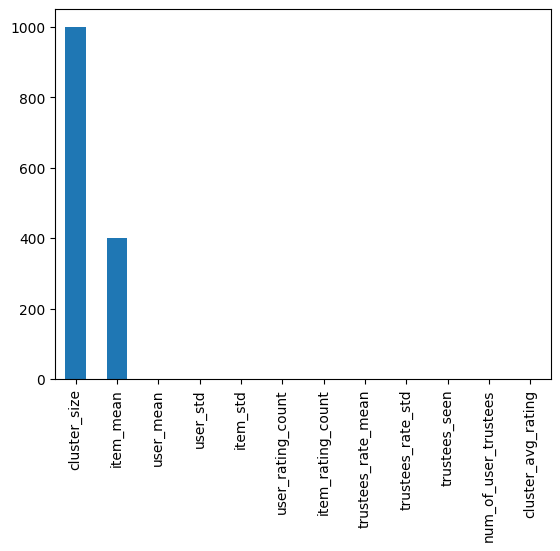

In [ ]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=200,             
    learning_rate=0.001,          
    max_depth=3,                   
    random_state=202,
    min_child_samples=20,
    reg_alpha=1.0,
    reg_lambda=1.0,
)

lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='rmse'
)

y_pred = lgbm_model.predict(X_val)
y_pred = np.round(y_pred.clip(0, 4) * 2) / 2

rmse = mean_squared_error(y_val, y_pred, squared=False)
mae = mean_absolute_error(y_val, y_pred)

importance = pd.Series(lgbm_model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(20).plot(kind='bar')

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

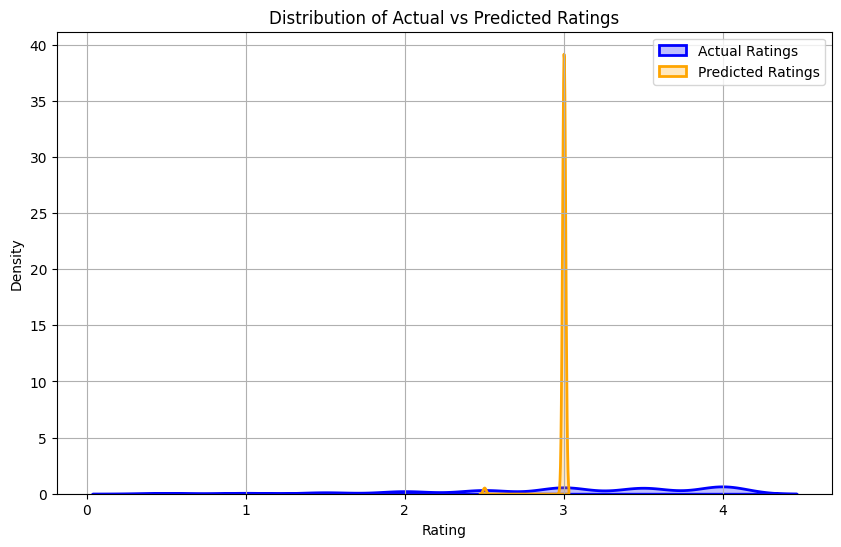

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# فرض بر اینکه y_val مقادیر واقعی و y_pred پیش‌بینی‌ها هستن
plt.figure(figsize=(10, 6))

sns.kdeplot(y_val, label='Actual Ratings', color='blue', fill=True, linewidth=2)
sns.kdeplot(y_pred, label='Predicted Ratings', color='orange', fill=True, linewidth=2)

plt.title('Distribution of Actual vs Predicted Ratings')
plt.xlabel('Rating')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()


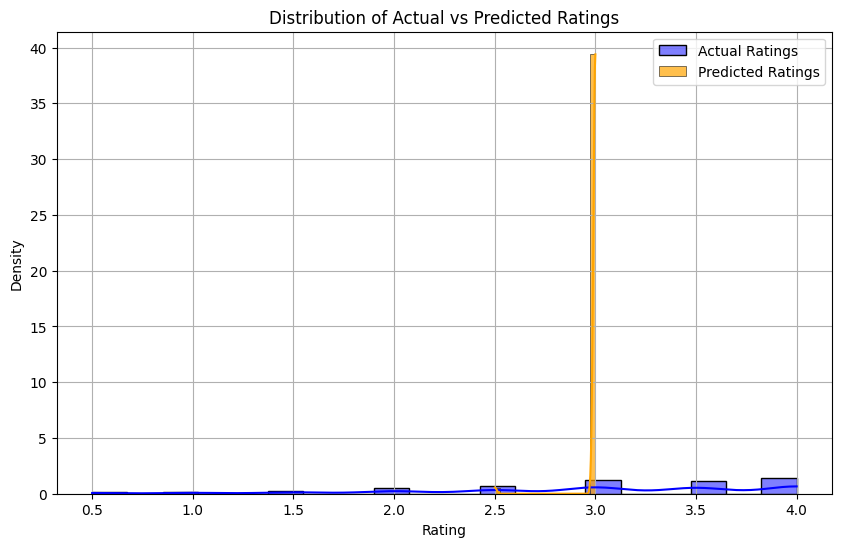

Train mean rating: 3.0071530106429507
Val mean rating: 3.0027336346406184


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(y_val, bins=20, color='blue', label='Actual Ratings', kde=True, stat='density')
sns.histplot(y_pred.clip(0,), bins=20, color='orange', label='Predicted Ratings', kde=True, stat='density', alpha=0.7)

plt.title('Distribution of Actual vs Predicted Ratings')
plt.xlabel('Rating')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

print("Train mean rating:", y_train.mean())
print("Val mean rating:", y_val.mean())

                      user_mean  user_std  item_mean  item_std  \
user_mean              1.000000 -0.596001   0.104517 -0.019300   
user_std              -0.596001  1.000000  -0.069208 -0.009064   
item_mean              0.104517 -0.069208   1.000000 -0.380368   
item_std              -0.019300 -0.009064  -0.380368  1.000000   
user_rating_count     -0.187390  0.150197  -0.117507 -0.157137   
item_rating_count      0.064831 -0.156720   0.146900  0.181225   
trustees_rate_mean    -0.051511  0.105662   0.068109 -0.182173   
trustees_rate_std     -0.063806  0.114754  -0.079404  0.032406   
trustees_seen         -0.017305  0.066711   0.030220  0.018027   
num_of_user_trustees  -0.058147  0.120037  -0.054560 -0.137727   
cluster_avg_rating     0.032785 -0.113607   0.060819  0.153166   
cluster_size           0.778608 -0.464051   0.151456 -0.045514   

                      user_rating_count  item_rating_count  \
user_mean                     -0.187390           0.064831   
user_std         

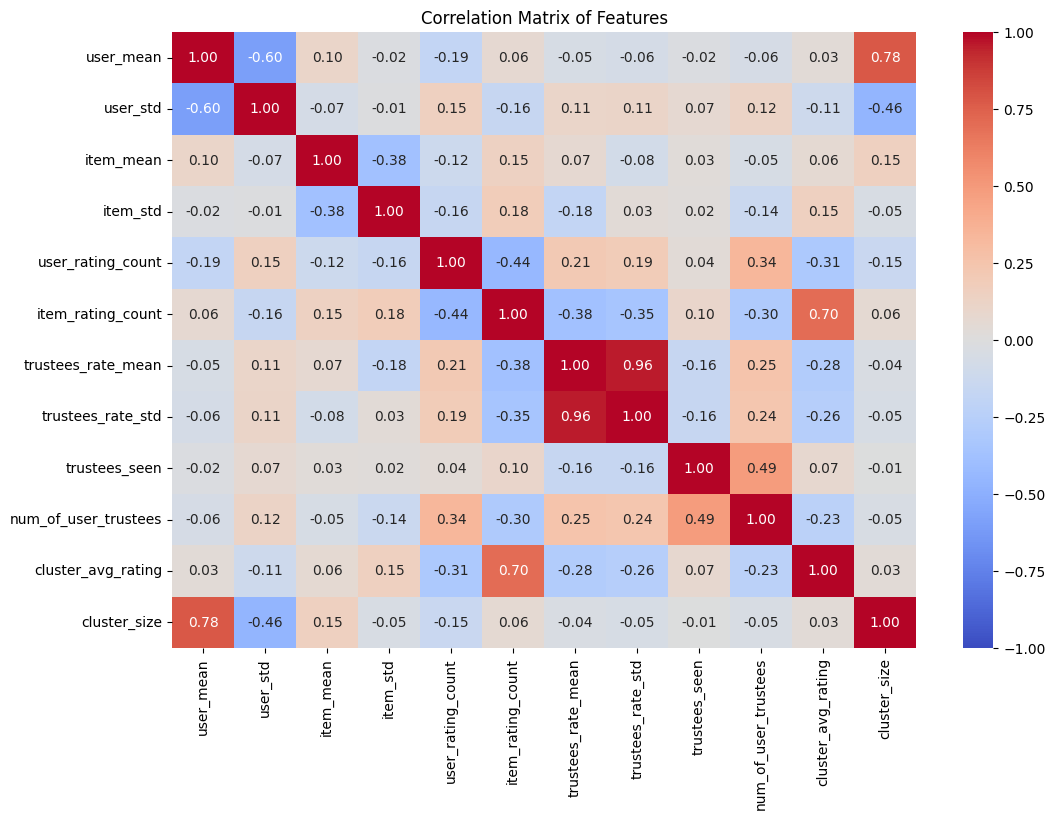

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# فرض کنیم دیتافریم تو اسمش df باشه
corr_matrix = df.drop(columns=[x for x in exclude_cols if x != 'id']).corr()

# نمایش عددی
print(corr_matrix)

# نمایش heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Features")
plt.show()


In [109]:
submit_df['id'] = range(1, len(test_df) + 1)

X_test = submit_df.drop(columns=exclude_cols, errors='ignore')

pred_rf = rf_model.predict(X_test)
# pred_lgbm = lgbm_model.predict(X_test)
# pred_cat = cat_model.predict(X_test)
# pred_xg = xgb_model.predict(X_test)

# ensemble_preds = (pred_lgbm + pred_rf) / 2 - 0.1

submission = pd.DataFrame({
    'id': test_df['id'],
    'label': np.clip(pred_rf, 0.5, 4)
})

def round_half(x):
    return round(x * 2) / 2

# submission['label'] = submission['label'].clip(0.5, 4).apply(round_half)
submission.to_csv('submission.csv', index=False)

/home/shahab/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


In [107]:
import numpy
print(numpy.__version__)

from surprise import Dataset, Reader
from surprise.model_selection import train_test_split
from surprise import SVD
from surprise import accuracy

# فرض کن df دیتای کاملت هست که شامل user_id, item_id, label (rating) هست
reader = Reader(rating_scale=(0, 5))
data = Dataset.load_from_df(df[['user_id', 'item_id', 'label']], reader)

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

model = SVD(n_factors=150, lr_all=0.005, reg_all=0.08, random_state=42, n_epochs=50)
model.fit(trainset)

predictions = model.test(testset)
print("RMSE:", accuracy.rmse(predictions))
print("MAE:", accuracy.mae(predictions))


1.26.4
RMSE: 0.7800
RMSE: 0.7800331327711185
MAE:  0.6057
MAE: 0.6057238280716628


In [115]:
predictions = []
for _, row in test_df.iterrows():
    uid = row['user_id']
    iid = row['item_id']
    pred = model.predict(uid, iid).est
    predictions.append(pred)
    
pred_rf = rf_model.predict(X_test)

submission = pd.DataFrame({
    'id': test_df['id'],
    'label': 0.8*np.array(predictions) + 0.2*np.array(pred_rf)
})
submission['label'] = np.clip(submission['label'], 0.5, 4)

submission.to_csv("submission.csv", index=False)

/home/shahab/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
